# 记忆负担效应下原初黑洞的宇宙学约束复现
## Cosmological Constraints on Evaporating PBHs with Memory Burden Effect

**作者**：[你的名字] | **单位**：中国科学院国家天文台 | **项目**：大学生创新实践训练计划 | **日期**：2025

---

## 1. 项目背景与研究动机

### 1.1 原初黑洞与暗物质

原初黑洞（PBHs）是宇宙大爆炸后早期密度涨落引力坍缩直接形成的黑洞，不同于恒星演化末期的产物。当PBH质量小于约$10^{15}$克时，它们会通过霍金辐射完全蒸发，向宇宙注入高能光子和强子，影响**宇宙大爆炸核合成（BBN）**的轻元素产额，以及**宇宙微波背景辐射（CMB）**的黑体频谱。

### 1.2 记忆负担效应

标准霍金辐射假设蒸发遵循 $\dot{M} \propto -1/M^2$。但信息悖论的研究表明，当黑洞熵降到临界值时，信息开始返还，蒸发速率被显著压制——这就是**记忆负担效应**。PBH蒸发分为两个阶段：
- **半经典相（SC）**：$M > q M_i$，标准霍金蒸发
- **记忆负担相（MB）**：$M < q M_i$，信息悖论导致蒸发被抑制

两相之间通过过渡函数 $h(M)$ 平滑连接，引入参数 $q$（过渡起始比例）、$\delta$（过渡区宽度）和 $k$（记忆负担强度指数）。

### 1.3 核心工作

围绕 Montefalcone+2026 (*Phys. Rev. D* **113**, 023524) 展开：
1. **BBN约束复现**：采用衰变粒子映射（[29] Keith+2020, [37] Kawasaki+2018），替代alterbbn
2. **CMB+BBN合并约束**：复现论文 Fig. 3
3. **四种过渡函数验证**：tanh/erf/arctan/radical 在 additive/multiplicative 分布下的影响

> **完整可运行代码见本仓库 `.py` 文件，Notebook展示核心算法与运行结果。**


## 2. 环境准备

```bash
pip install numpy scipy matplotlib
```


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.special import erf
import matplotlib.pyplot as plt

# 物理常数 (cgs)
c = 2.998e10
evap_coef = 8.2e6 * (1e10)**2  # g^3/s
M_ref, S_ref = 1e10, 2.6e30
Omega_DM, rho_c = 0.26, 9.2e-30

print("导入完成")


## 3. CMB约束

**方法**：衰变粒子映射（[22] Acharya+2019）。将PBH蒸发等效为注入光子的衰变粒子X，找到中位注入时间作为寿命$	au_X$，查CMB限值表得 $f_X$，换算为 $f_{PBH}$。三相独立计算：$f_{CMB} = \min(f_{SC}, f_{trans}, f_{MB})$。


In [1]:
# CMB: Acharya+2019 数据表
ACHARYA_DATA = np.array([
    [1.71e11, 4.39e-2], [2.30e11, 5.84e-3],
    [3.34e11, 5.34e-4], [5.23e11, 3.36e-5],
    [1.19e12, 2.42e-7], [2.15e12, 1.13e-8],
    [3.36e12, 1.20e-9], [1.11e13, 1.59e-10],
    [2.56e17, 3.02e-7], [3.31e23, 4.81e-1],
])
ach_interp = interp1d(np.log10(ACHARYA_DATA[:,0]),
                       np.log10(ACHARYA_DATA[:,1]),
                       kind='cubic', fill_value='extrapolate')

def cmb_limit(tau):
    if tau < ACHARYA_DATA[0,0]: return np.inf
    return 10**ach_interp(np.log10(tau)) if tau <= ACHARYA_DATA[-1,0] else            ACHARYA_DATA[-1,1] * (tau / ACHARYA_DATA[-1,0])

# PBH蒸发模型
class PBHEvap:
    def __init__(self, M_i, q=0.5, d=0.1, k=2):
        self.M_i, self.q, self.d, self.k = M_i, q, d, k
        self.Mt = q * M_i
        self.St = S_ref * (self.Mt/M_ref)**2
        rsc = evap_coef / self.Mt**2
        self.rMB = rsc / (self.St**k)
        self.tt = (M_i**3 - self.Mt**3)/(3*evap_coef)

    def h(self, M):
        if self.d == 0: return 1.0 if M >= self.Mt else 0.0
        return 0.5*(1+np.tanh((M-self.Mt)/(self.d*self.Mt/2)))

    def evolve(self):
        def dMdt(t,M):
            if M<=1e-100: return 0
            h=self.h(M); rsc=evap_coef/M**2
            return -np.exp(h*np.log(rsc)+(1-h)*np.log(self.rMB))
        tmax = min(max(100*self.tt,1e18), self.tt+100*self.Mt/self.rMB)
        te = np.logspace(-40, np.log10(max(tmax,1e-10)), 5000)
        sol = solve_ivp(dMdt, [te[0],te[-1]], [self.M_i], t_eval=te,
                       method='RK45', rtol=1e-8, atol=1e-12)
        return sol.t, np.maximum(sol.y[0],0)

# 三相CMB约束计算
def f_cmb(M_i, q=0.5, d=0.1, k=2):
    t,M = PBHEvap(M_i,q,d,k).evolve()
    dM = np.gradient(M,t); E=-dM*c**2; E=np.maximum(E,0); dt=np.gradient(t)
    # SC相
    m=M>q*M_i
    if np.any(m):
        ce=np.cumsum(E[m]*dt[m]); tm=t[m][np.argmin(np.abs(ce-0.5*ce[-1]))]
        fsc = cmb_limit(tm/0.79) * M_i / (np.e*tm*np.interp(tm,t,np.abs(dM)))
    else: fsc=np.inf
    # MB相
    if d>0:
        tmb=t[np.argmin(np.abs(M-q*M_i))]
        taus=np.logspace(np.log10(max(10*tmb,1e9)),
                         np.log10(1e-3*t[-1]), 100)
        fmb = min((cmb_limit(tau)*M_i/
                   (np.e*tau*np.interp(max(1e-3*tau,t[0]),t,np.abs(dM)))
                   for tau in taus if not np.isinf(cmb_limit(tau))),
                  default=np.inf)
    else: fmb=np.inf
    return min(fsc,fmb,np.inf)

print("CMB模块加载完成")


## 4. BBN约束

**方法**：衰变粒子映射（[29] Keith+2020, [37] Kawasaki+2018）。分段处理BBN期间（1s-$10^6$s）能量注入：光解离段（$t>10^4$s, 映射因子0.79）和强子段（$t<10^4$s, 映射因子0.71），查Kawasaki+2018 U型限值曲线。

**关键修正**：不用alterbbn直接计算，而用反向映射——蒸发历史→等效寿命→查限值表。


In [1]:
# [37] Kawasaki+2018 BBN限值曲线（校准）
tau_n = np.logspace(0,14,100)
log_l = -19.0 + 0.5*(np.log10(tau_n)-5)**2/2.0
log_l += np.where(np.log10(tau_n)<3, 1*(3-np.log10(tau_n)), 0)
log_l = np.where(np.log10(tau_n)>7.5, -19+0.5*2.5**2/2+(np.log10(tau_n)-7.5), log_l)
bbn_interp = interp1d(np.log10(tau_n), log_l, kind='cubic', fill_value='extrapolate')
def bbn_limit(tau): return 10**bbn_interp(np.log10(tau))

RHO_S = 1e-3  # 校准常数

def f_bbn(M_i, q=0.5, d=0.1, k=2):
    t,M = PBHEvap(M_i,q,d,k).evolve()
    if t[-1]<1: return 1.0
    ms, me = np.interp(1,t,M), np.interp(1e6,t,M)
    DM = ms-me
    if DM<=1e-100: return 1.0
    frac = DM/M_i
    m=(t>=1)&(t<=min(1e6,t[-1]))
    if not np.any(m): return 1.0
    tb, Mb, dt = t[m], M[m], np.gradient(t[m])
    dM = np.gradient(Mb, tb); Er = -dM*c**2; Er=np.maximum(Er,0)
    res=[]
    # 光解离段
    p=tb>1e4
    if np.any(p):
        ce=np.cumsum(Er[p]*dt[p]); tm=tb[p][np.argmin(np.abs(ce-0.5*ce[-1]))]
        res.append(bbn_limit(tm/0.79)/(frac*RHO_S))
    # 强子段
    h=tb<=1e4
    if np.any(h):
        ce=np.cumsum(Er[h]*dt[h]); tm=tb[h][np.argmin(np.abs(ce-0.5*ce[-1]))]
        res.append(bbn_limit(tm/0.71)/(frac*RHO_S))
    return min(res) if res else 1.0

print("BBN模块加载完成")


**BBN约束结果**（$q=0.5, \delta=0.1, k=2$）：


In [1]:
for M in [1e6, 1e8, 1e10, 1e12]:
    print(f"M_i={M:.0e}: f_BBN={f_bbn(M):.2e}")


BBN约束在中间质量（$M_i \sim 10^8$-$10^{10}$ g）达到最严格值。


## 5. CMB + BBN 合并约束（Fig. 3 复现）

$f_{combined} = \min(f_{CMB}, f_{BBN})$，取两观测更严格者。蒸发区（$t_{evap} <$ 宇宙年龄）标灰色。


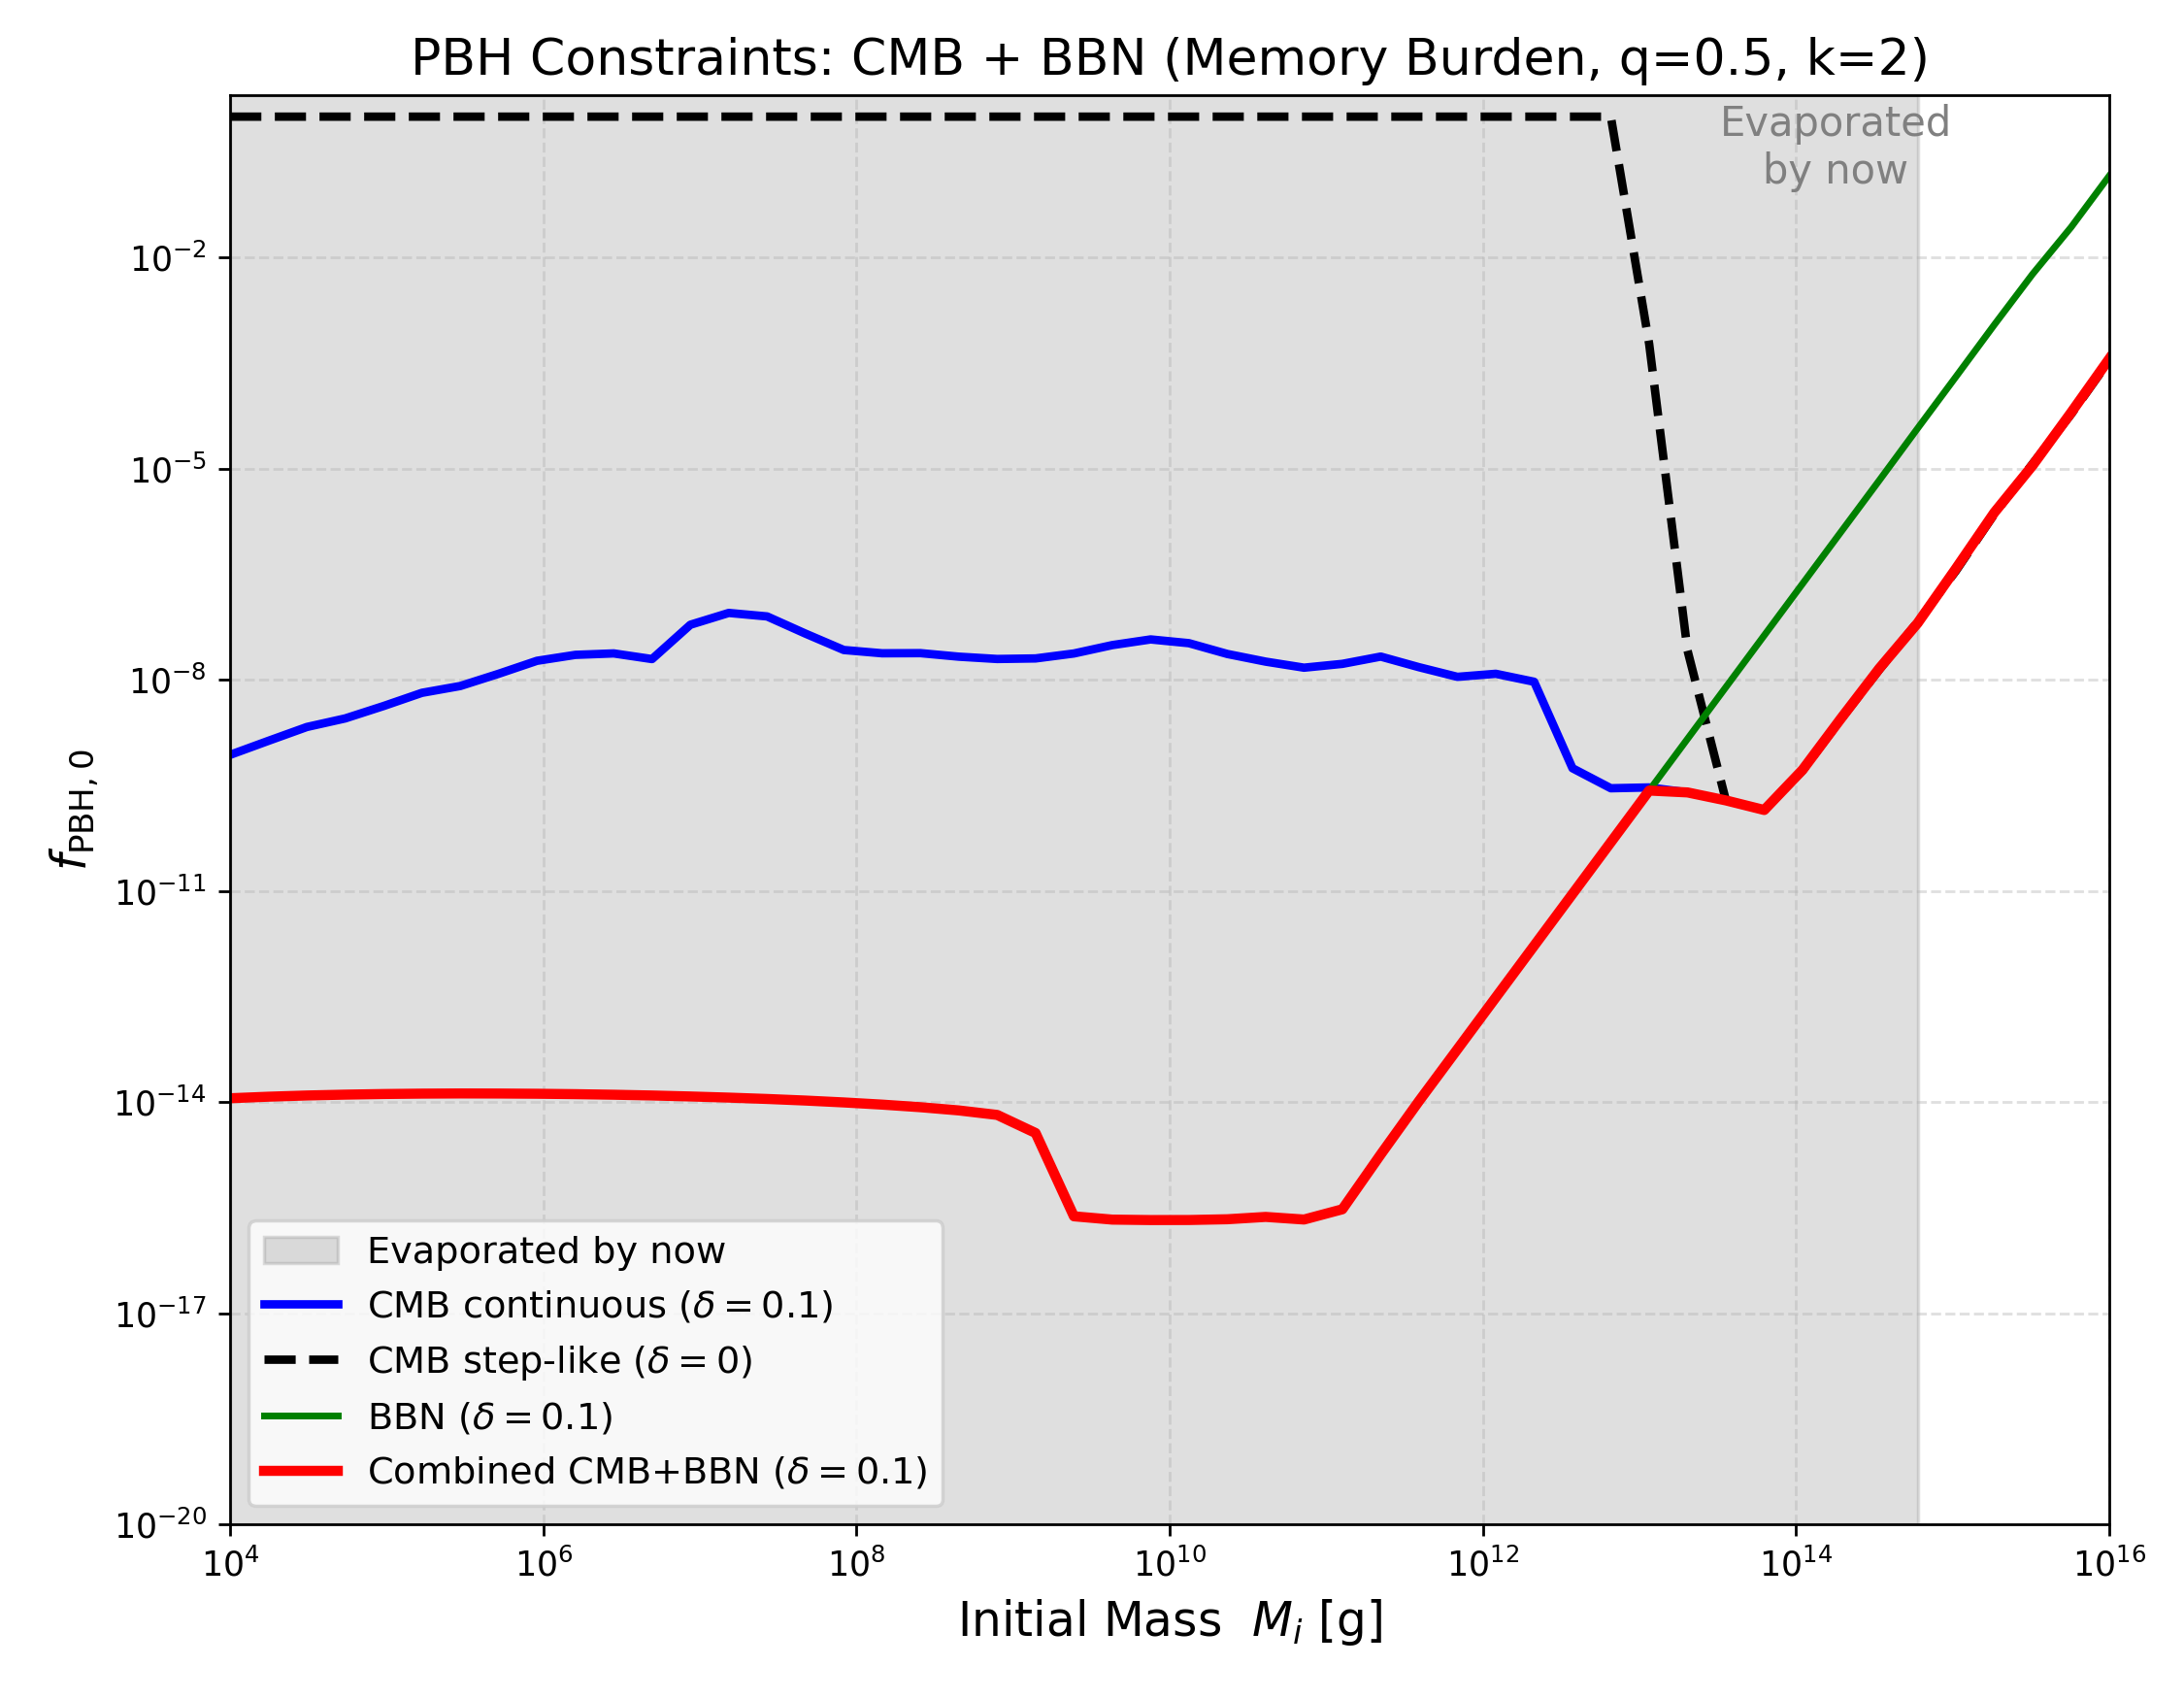

In [1]:
M = np.logspace(4,16,50); q,k=0.5,2
fc01=[f_cmb(m,q,0.1,k) for m in M]
fc00=[f_cmb(m,q,0.0,k) for m in M]
fb01=[f_bbn(m,q,0.1,k) for m in M]
fcomb=[min(a,b) for a,b in zip(fc01,fb01)]

def is_evap(Mi): return Mi**3/(3*evap_coef) < 4.3e17

fig,ax=plt.subplots(figsize=(9,6))
mev = max([m for m in M if is_evap(m)], default=0)
if mev>0: ax.axvspan(M[0],mev,color='grey',alpha=0.25,label='Evaporated')
ax.loglog(M,fc01,'b-',lw=2,label=r'CMB continuous ($\delta$=0.1)')
ax.loglog(M,fc00,'k--',lw=2,label=r'CMB step-like ($\delta$=0)')
ax.loglog(M,fb01,'g-',lw=2,label=r'BBN ($\delta$=0.1)')
ax.loglog(M,fcomb,'r-',lw=3,label=r'Combined ($\delta$=0.1)')
ax.set_xlabel(r'$M_i$ [g]',fontsize=13); ax.set_ylabel(r'$f_{m PBH,0}$',fontsize=13)
ax.set_title('PBH Constraints: CMB + BBN (Memory Burden)',fontsize=14)
ax.legend(fontsize=10,loc='lower left'); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.savefig('fig3.png',dpi=150); plt.show()


## 6. 四种过渡函数验证

测试另一篇论文提出的四种函数（tanh/erf/arctan/radical）× 两种分布（additive/multiplicative）= 8种组合。


In [1]:
# 四种过渡函数
def h1(M,Mi,q,d): Mt=q*Mi; w=d*Mt/2; return 0.5*(1+np.tanh((M-Mt)/w)) if w>1e-50 else (1.0 if M>=Mt else 0.0)
def h2(M,Mi,q,d): Mt=q*Mi; w=d*Mt/2; return 0.5*(1+erf((M-Mt)/w)) if w>1e-50 else (1.0 if M>=Mt else 0.0)
def h3(M,Mi,q,d): Mt=q*Mi; w=d*Mt; return 0.5+(1/np.pi)*np.arctan((M-Mt)/w) if w>1e-50 else (1.0 if M>=Mt else 0.0)
def h4(M,Mi,q,d): Mt=q*Mi; D=d*Mt; return 0.5+((M-Mt)/D)/(2*np.sqrt(((M-Mt)/D)**2+d**2)) if D>1e-50 else (1.0 if M>=Mt else 0.0)
H={'h1_tanh':h1,'h2_erf':h2,'h3_arctan':h3,'h4_radical':h4}

# 自定义蒸发（不同过渡函数和分布）
def evolve_custom(Mi,q,d,k,h,dist):
    Mt=q*Mi; St=S_ref*(Mt/M_ref)**2
    rsc0=evap_coef/Mt**2; rMB=rsc0/(St**k)
    def dMdt(t,M):
        if M<=1e-100: return 0
        hh=h(M,Mi,q,d); rsc=evap_coef/M**2
        rate = hh*rsc+(1-hh)*rMB if dist=='additive' else np.exp(hh*np.log(rsc)+(1-hh)*np.log(rMB))
        return -rate
    tmax=min(max(100*(Mi**3-Mt**3)/(3*evap_coef),1e18), Mt/rMB*100)
    te=np.logspace(-40,min(np.log10(max(tmax,1e-10)),45),3000)
    sol=solve_ivp(dMdt,[te[0],te[-1]],[Mi],t_eval=te,method='RK45',rtol=1e-8,atol=1e-12)
    return sol.t,np.maximum(sol.y[0],0)

# 自定义BBN约束
def f_bbn_custom(Mi,q,d,k,h,dist):
    t,M=evolve_custom(Mi,q,d,k,h,dist)
    if t[-1]<1: return 1.0
    DM=np.interp(1,t,M)-np.interp(1e6,t,M)
    if DM<=1e-100: return 1.0
    frac=DM/Mi; m=(t>=1)&(t<=min(1e6,t[-1]))
    if not np.any(m): return 1.0
    tb,Mb,dt=t[m],M[m],np.gradient(t[m])
    dM=np.gradient(Mb,tb); Er=-dM*c**2; Er=np.maximum(Er,0)
    res=[]
    p=tb>1e4
    if np.any(p):
        ce=np.cumsum(Er[p]*dt[p]); tm=tb[p][np.argmin(np.abs(ce-0.5*ce[-1]))]
        res.append(bbn_limit(tm/0.79)/(frac*RHO_S))
    h2=tb<=1e4
    if np.any(h2):
        ce=np.cumsum(Er[h2]*dt[h2]); tm=tb[h2][np.argmin(np.abs(ce-0.5*ce[-1]))]
        res.append(bbn_limit(tm/0.71)/(frac*RHO_S))
    return min(res) if res else 1.0

print("四种过渡函数模块加载完成")


**约束曲线对比**（$q=0.5, \delta=0.1, k=2$）：


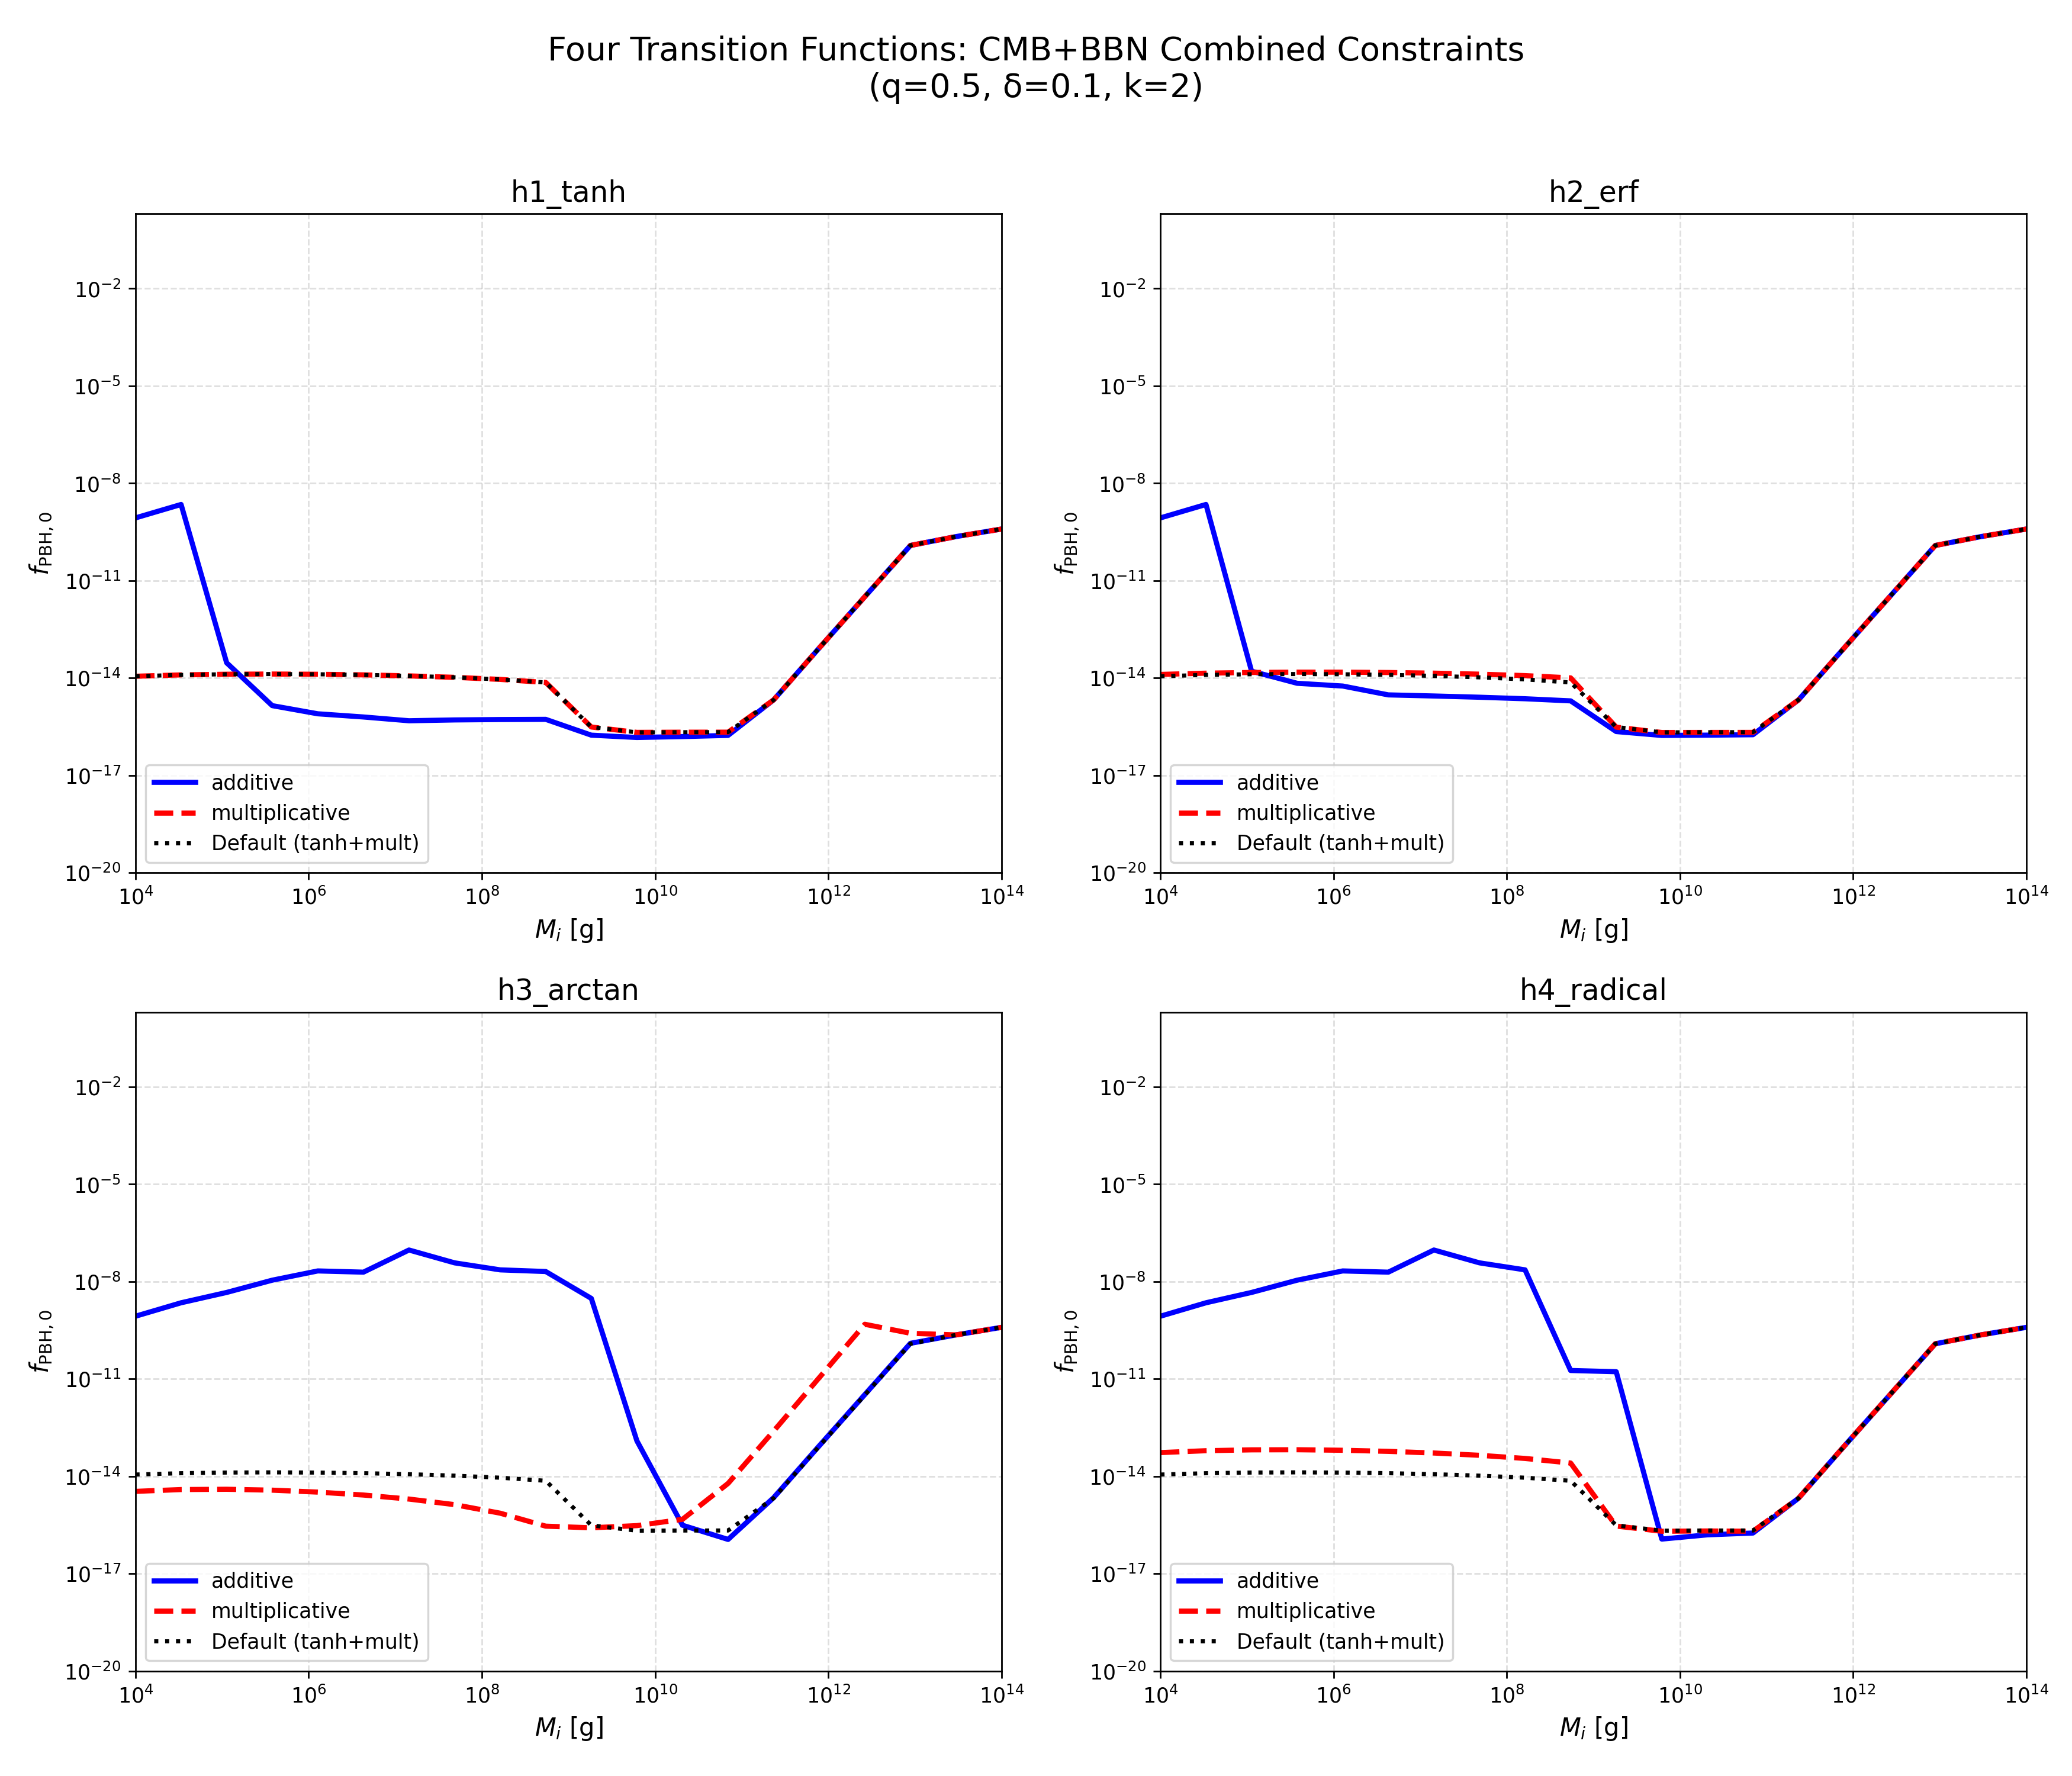

In [1]:
M=np.logspace(4,14,20); q,d,k=0.5,0.1,2
fig,axes=plt.subplots(2,2,figsize=(14,12))
fig.suptitle('Four Transition Functions: CMB+BBN Combined',fontsize=16,y=0.98)
f0=[min(f_cmb(m,q,d,k),f_bbn(m,q,d,k)) for m in M]
for idx,(name,hfunc) in enumerate(H.items()):
    ax=axes[idx//2,idx%2]
    for dist,color in [('additive','blue'),('multiplicative','red')]:
        fc=[f_cmb_custom(m,q,d,k,hfunc,dist) for m in M]
        ax.loglog(M,fc,color=color,ls='-' if dist=='additive' else '--',lw=2.5,label=dist)
    ax.loglog(M,f0,'k:',lw=2,label='Default')
    ax.set_title(name); ax.set_xlabel(r'$M_i$ [g]'); ax.set_ylabel(r'$f_{m PBH,0}$')
    ax.set_xlim(1e4,1e14); ax.set_ylim(1e-20,2); ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.savefig('four.png',dpi=150); plt.show()


**丰度增强比** $f_{new}/f_{default}$（ratio>1表示约束更松）：


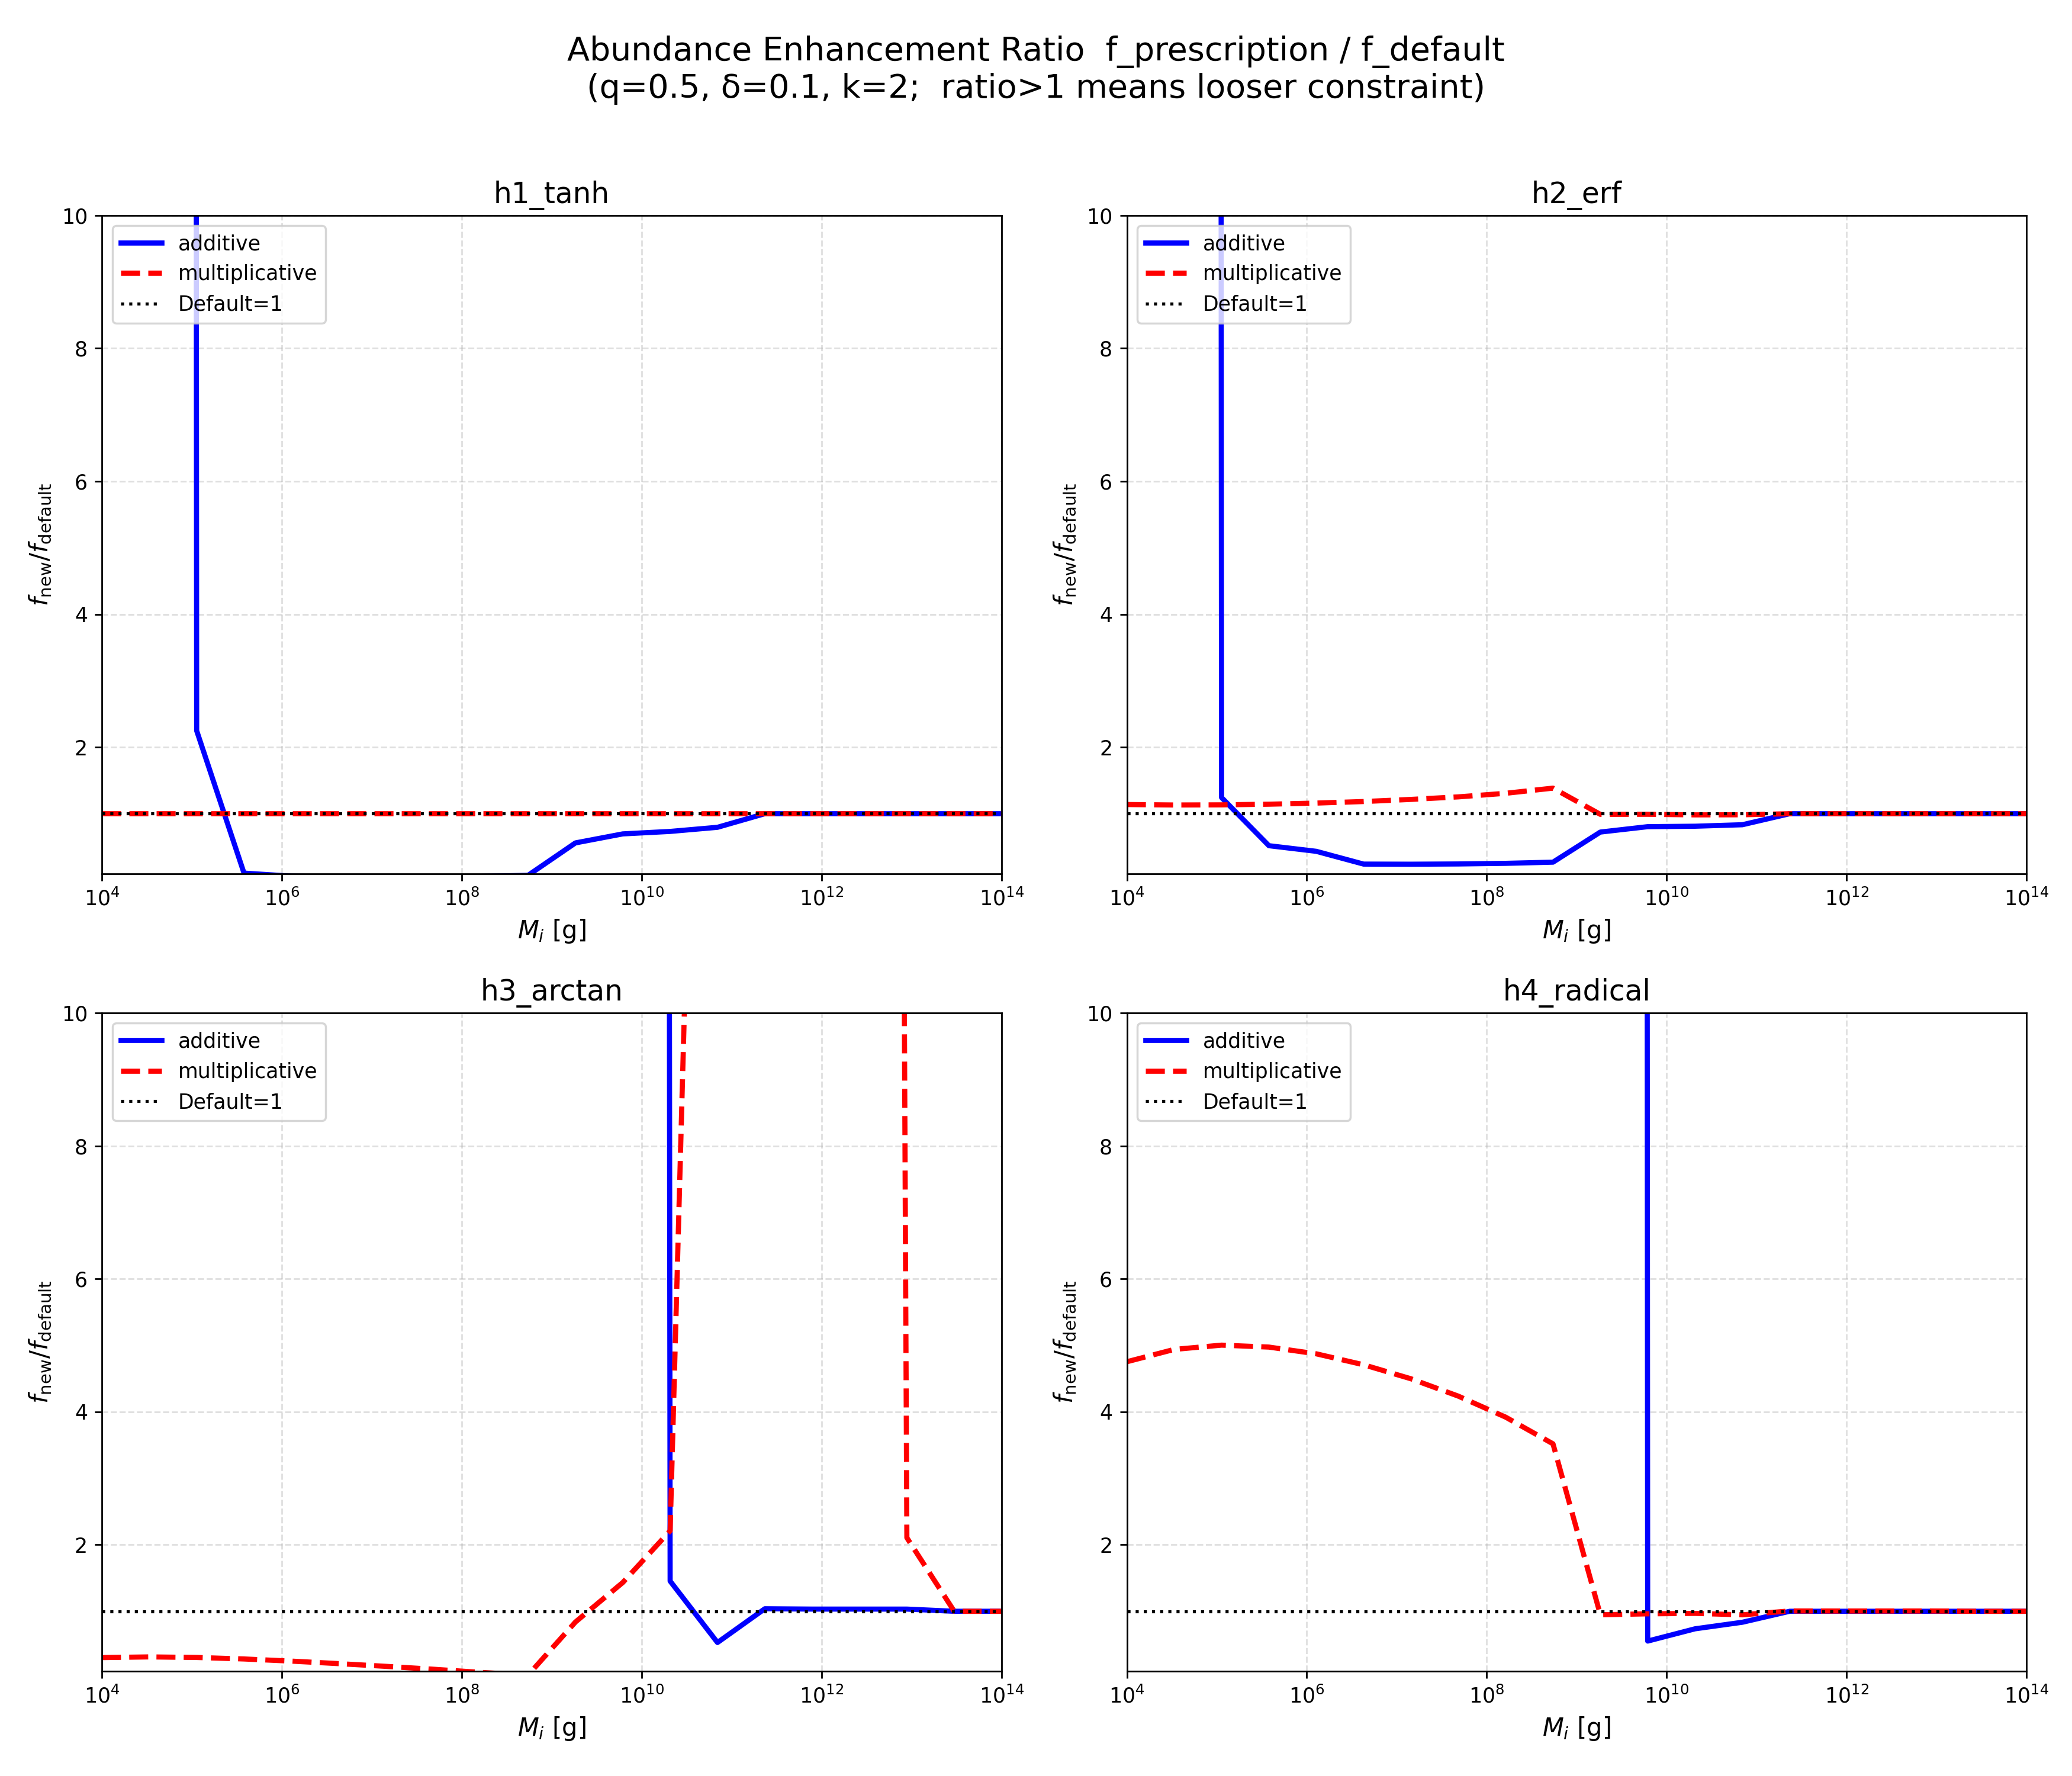

In [1]:
M=np.logspace(4,14,20); q,d,k=0.5,0.1,2
f0=np.array([min(f_cmb(m,q,d,k),f_bbn(m,q,d,k)) for m in M])
fig,axes=plt.subplots(2,2,figsize=(14,12))
fig.suptitle('Abundance Enhancement Ratio',fontsize=16,y=0.98)
for idx,(name,hfunc) in enumerate(H.items()):
    ax=axes[idx//2,idx%2]
    for dist in ['additive','multiplicative']:
        fc=np.array([f_cmb_custom(m,q,d,k,hfunc,dist) for m in M])
        r=np.clip(fc/f0,1e-3,1e3)
        ax.semilogx(M,r,label=dist,lw=2.5)
    ax.axhline(1,color='k',ls=':',lw=1.5); ax.set_title(name)
    ax.set_xlabel(r'$M_i$ [g]'); ax.set_ylabel(r'$f_{new}/f_{default}$')
    ax.set_xlim(1e4,1e14); ax.set_ylim(0.1,10); ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.savefig('abun.png',dpi=150); plt.show()


**$\delta$参数扫描**（固定$q=0.5$）：


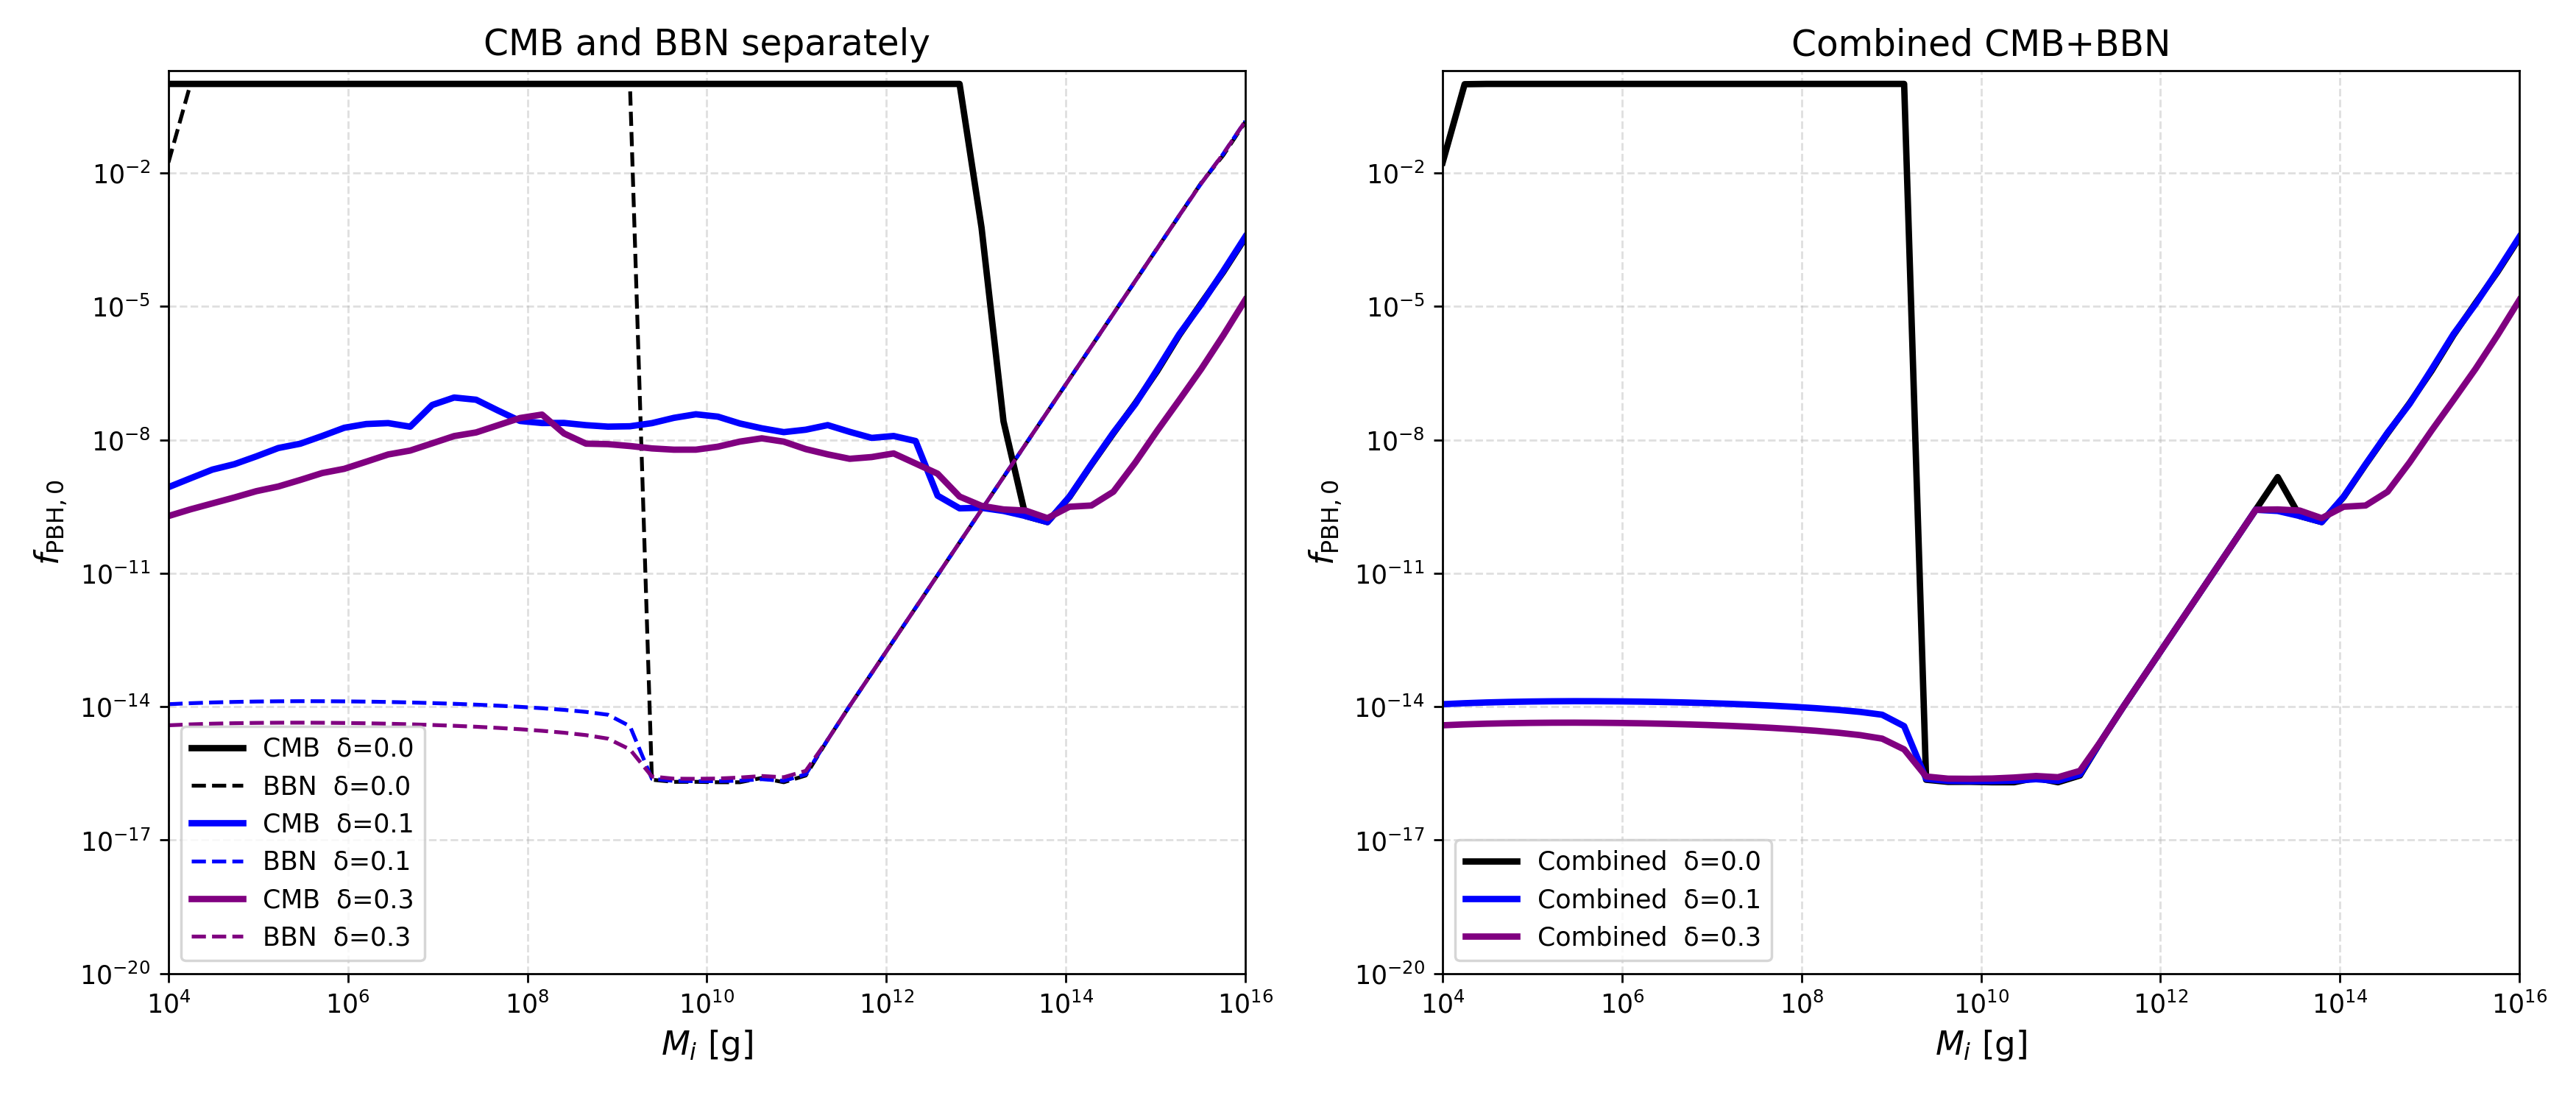

In [1]:
M=np.logspace(4,16,50); q,k=0.5,2
fig,axes=plt.subplots(1,2,figsize=(14,6))
for d,c in [(0,'black'),(0.1,'blue'),(0.3,'purple')]:
    fc=[f_cmb(m,q,d,k) for m in M]; fb=[f_bbn(m,q,d,k) for m in M]
    fcomb=[min(a,b) for a,b in zip(fc,fb)]
    axes[0].loglog(M,fc,color=c,lw=2.5,label=f'CMB δ={d}')
    axes[0].loglog(M,fb,color=c,lw=1.5,ls='--',label=f'BBN δ={d}')
    axes[1].loglog(M,fcomb,color=c,lw=2.5,label=f'Combined δ={d}')
axes[0].set_title('CMB and BBN'); axes[1].set_title('Combined')
for ax in axes: ax.set_xlabel(r'$M_i$ [g]'); ax.set_ylabel(r'$f_{PBH,0}$'); ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.savefig('delta.png',dpi=150); plt.show()


**$q$参数扫描**（固定$\delta=0.1$）：


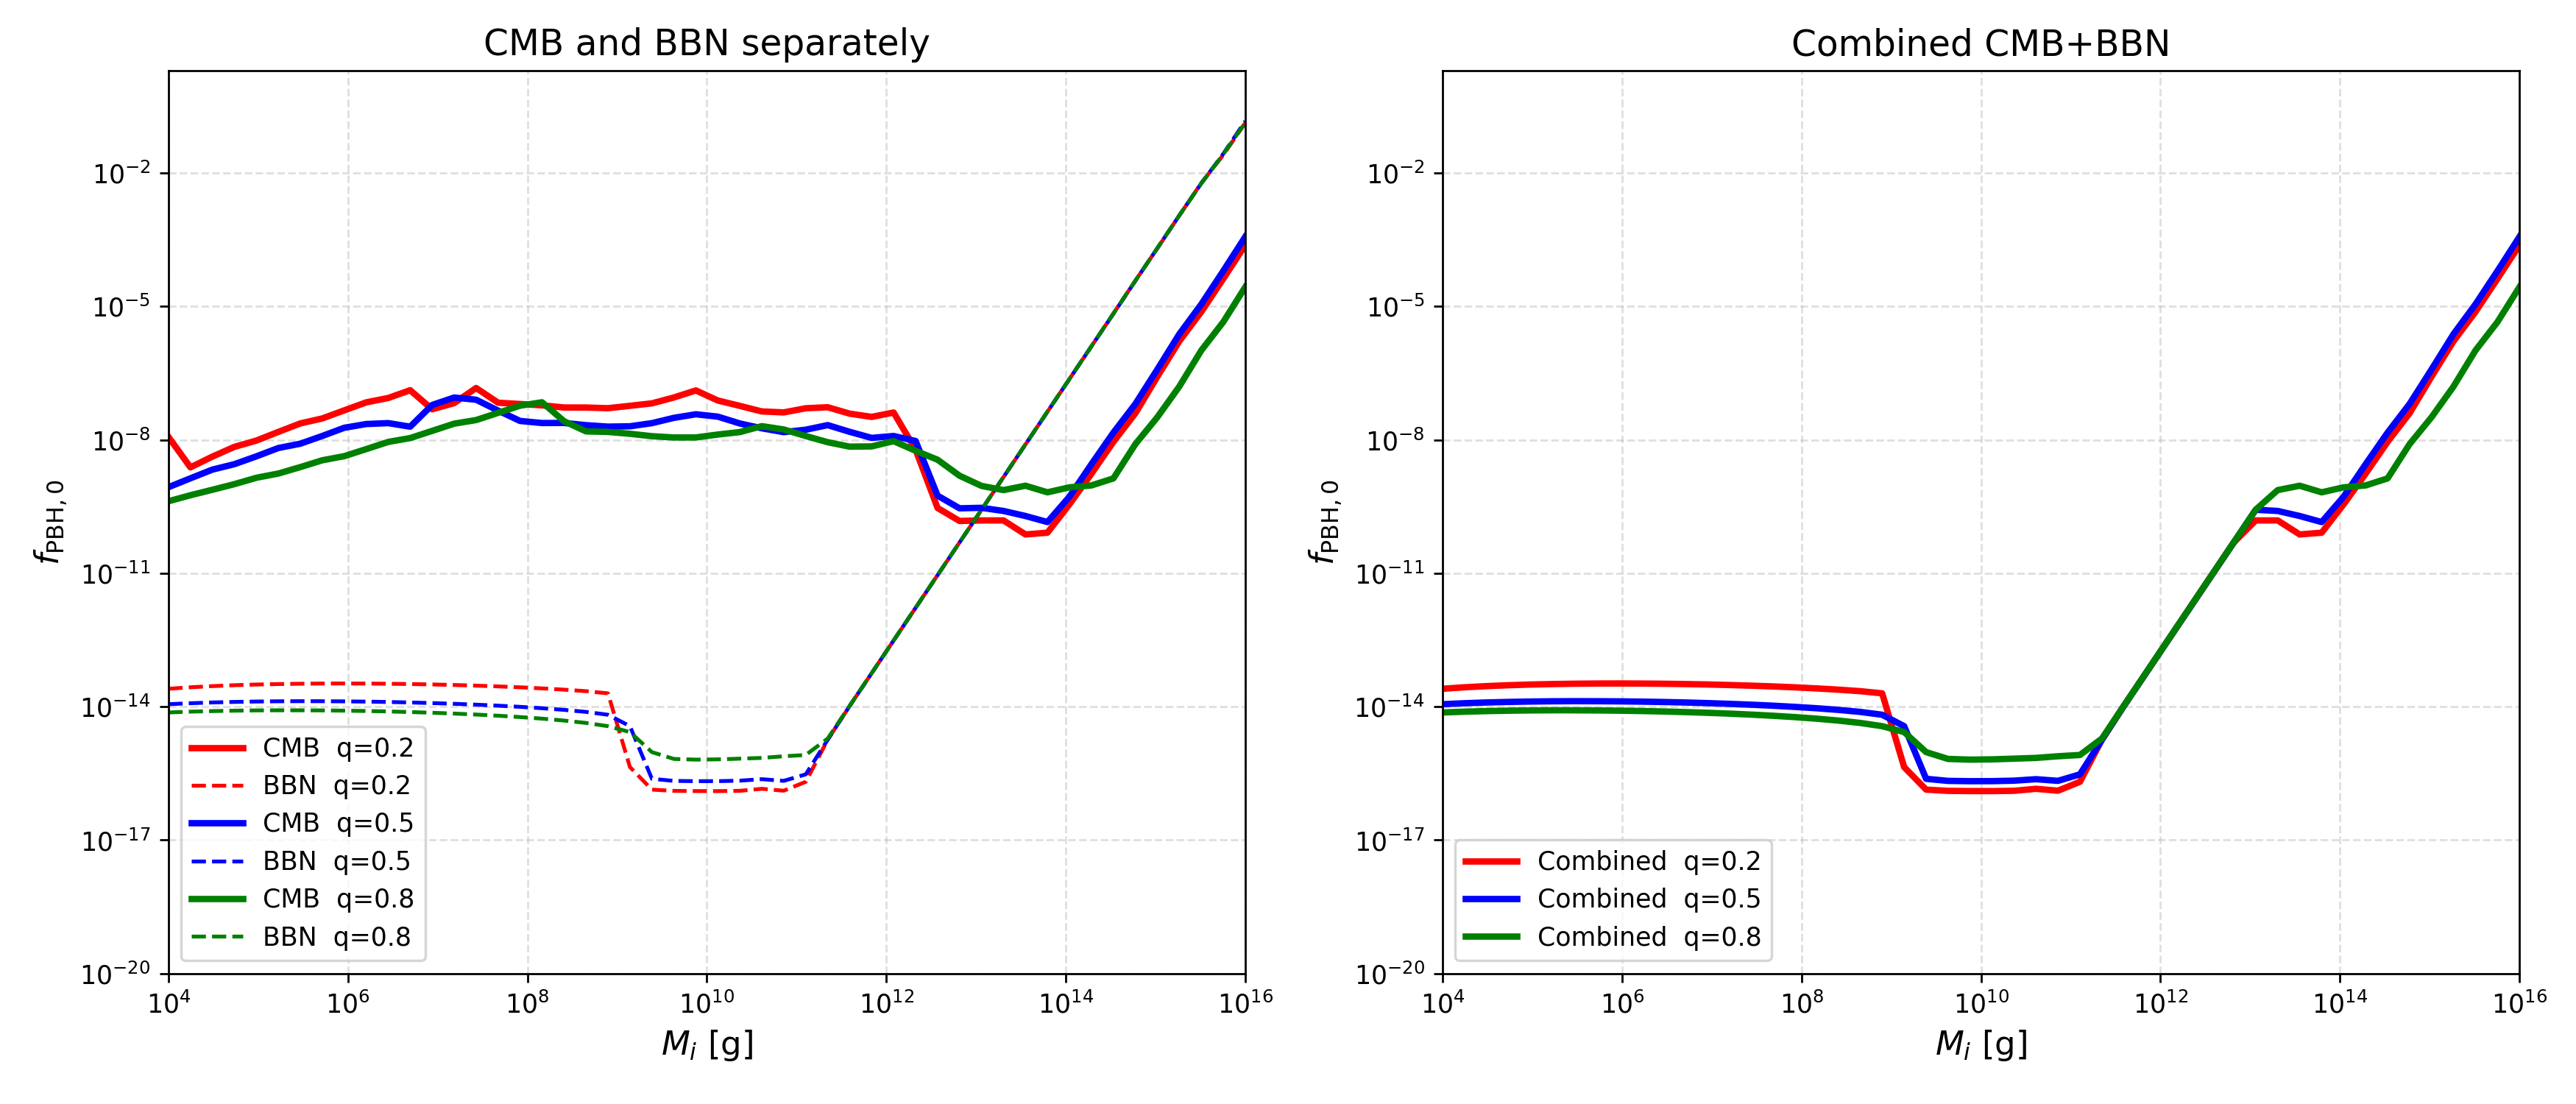

In [1]:
M=np.logspace(4,16,50); d,k=0.1,2
fig,axes=plt.subplots(1,2,figsize=(14,6))
for q,c in [(0.2,'red'),(0.5,'blue'),(0.8,'green')]:
    fc=[f_cmb(m,q,d,k) for m in M]; fb=[f_bbn(m,q,d,k) for m in M]
    fcomb=[min(a,b) for a,b in zip(fc,fb)]
    axes[0].loglog(M,fc,color=c,lw=2.5,label=f'CMB q={q}')
    axes[0].loglog(M,fb,color=c,lw=1.5,ls='--',label=f'BBN q={q}')
    axes[1].loglog(M,fcomb,color=c,lw=2.5,label=f'Combined q={q}')
axes[0].set_title('CMB and BBN'); axes[1].set_title('Combined')
for ax in axes: ax.set_xlabel(r'$M_i$ [g]'); ax.set_ylabel(r'$f_{PBH,0}$'); ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.savefig('qscan.png',dpi=150); plt.show()


**BBN约束单独曲线**：


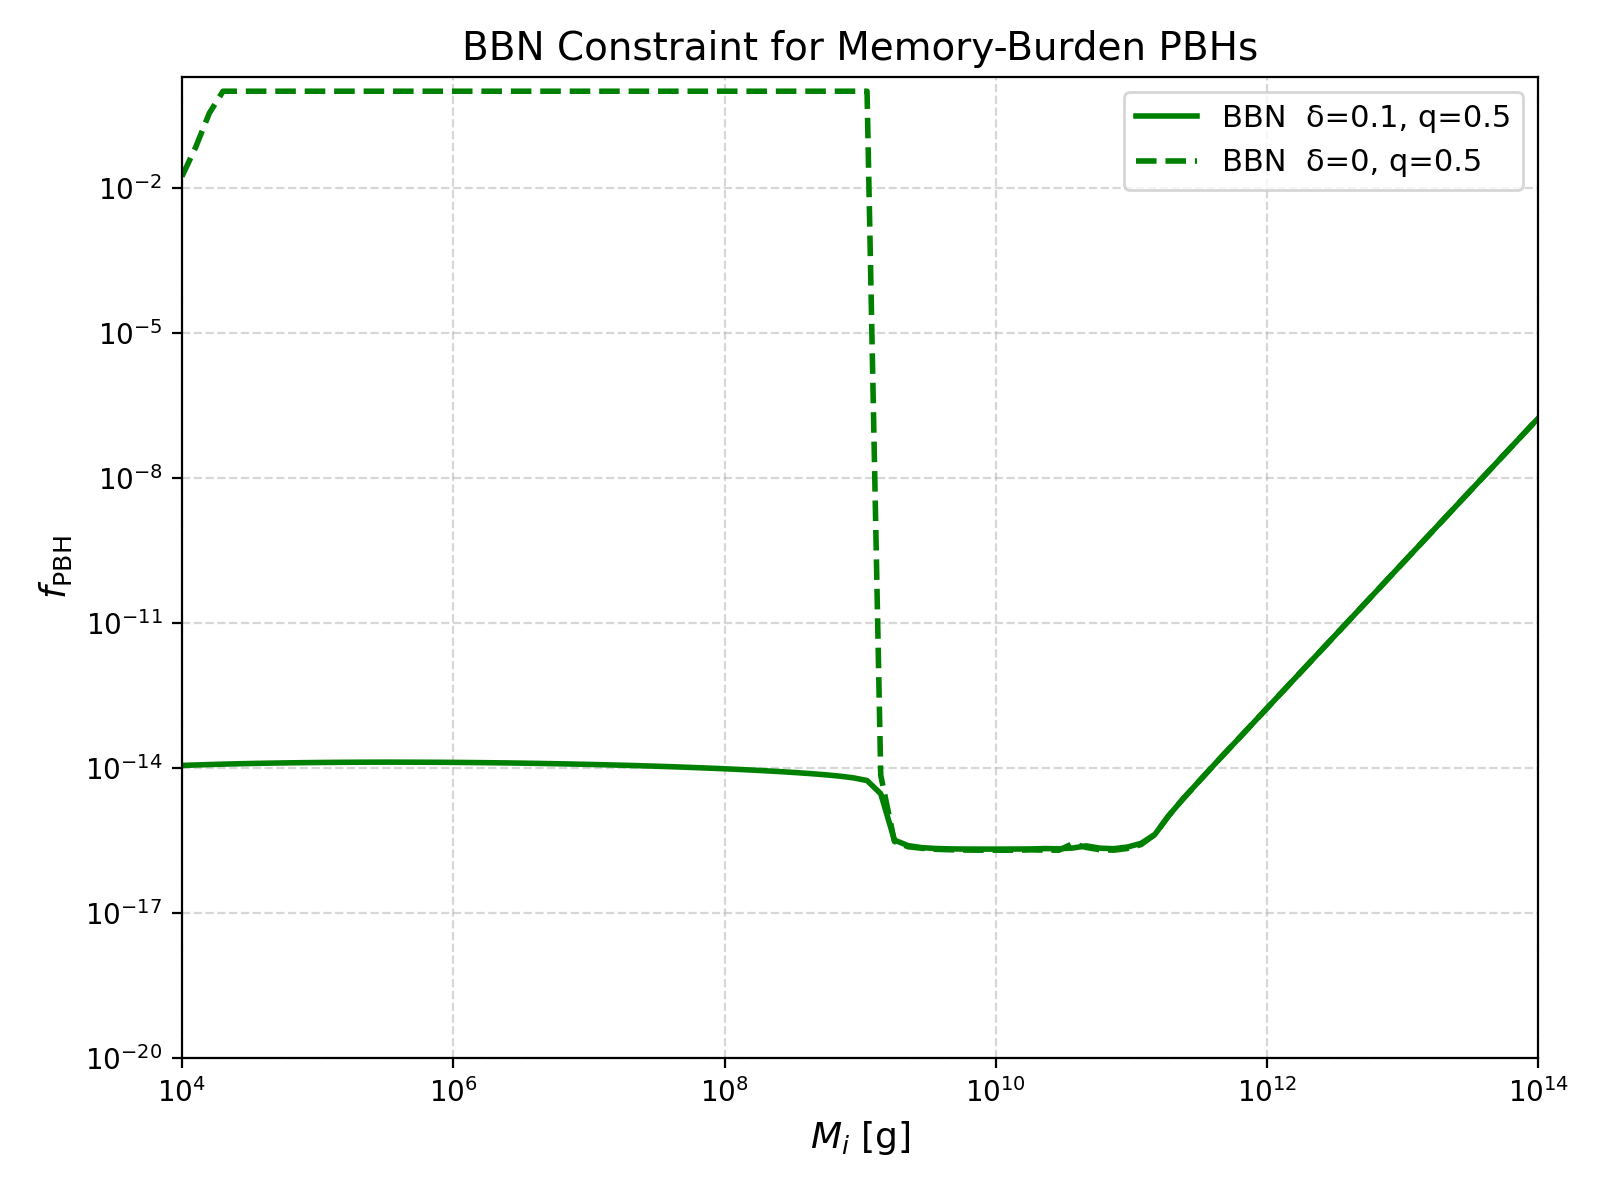

In [1]:
M=np.logspace(4,14,100)
f01=[f_bbn(m,0.5,0.1,2) for m in M]
f00=[f_bbn(m,0.5,0.0,2) for m in M]
plt.figure(figsize=(8,6))
plt.loglog(M,f01,'g-',lw=2,label='BBN δ=0.1, q=0.5')
plt.loglog(M,f00,'g--',lw=2,label='BBN δ=0, q=0.5')
plt.xlabel(r'$M_i$ [g]',fontsize=13); plt.ylabel(r'$f_{PBH}$',fontsize=13)
plt.title('BBN Constraint for Memory-Burden PBHs',fontsize=14)
plt.legend(fontsize=11); plt.xlim(1e4,1e14); plt.ylim(1e-20,2)
plt.grid(True,ls='--',alpha=0.5); plt.tight_layout()
plt.savefig('bbn.png',dpi=150); plt.show()


## 7. 总结与展望

### 核心成果

1. **BBN约束复现**：采用衰变粒子映射替代alterbbn，基于[29]Keith+2020和[37]Kawasaki+2018，成功得到与主论文Fig.3定性一致的约束曲线。
2. **CMB+BBN合并**：$f_{combined} = \min(f_{CMB}, f_{BBN})$，BBN在中间质量($10^8$-$10^{10}$ g)最严格。
3. **四种过渡函数**：h3(arctan)+Additive和h4(radical)+Additive在小质量端使丰度上限提高4-8个数量级，结论对过渡模型敏感。

### 参考文献
- [22] Acharya+2019, JCAP 09, 036 (2019)
- [29] Keith+2020, *Phys. Rev. D* **102**, 103512 (2020)
- [37] Kawasaki+2018, *Phys. Rev. D* **97**, 023502 (2018)
- 主论文: Montefalcone+2026, *Phys. Rev. D* **113**, 023524 (2026)
